# Duffing Oscillator (Example 2): Lyapunov Functions via Koopman Eigenfunctions — Corrected Notebook

This notebook redoes `Lyapunov_2.ipynb`'s Duffing-oscillator example (**Example 2** in
*"Kernel Methods for the Construction of Certified Lyapunov Functions via Approximate Koopman
Eigenfunctions"*) and fixes three bugs found in the original, then adds explicit checks that the
computed function is a **strict** Lyapunov function (the paper's whole point in this example).

**System (paper eq. 49):**
$$\dot x_1 = x_2, \qquad \dot x_2 = -\delta x_2 - \alpha x_1 - \beta x_1^3,$$
with $\alpha=1,\ \beta=3,\ \delta=4$ (overdamped, real eigenvalues
$\lambda_1\approx-0.2679,\ \lambda_2\approx-3.7321$).

**Why this matters for "strictness":** the classical mechanical-energy function
$$V(x)=\tfrac12 x_2^2+\tfrac12\alpha x_1^2+\tfrac14\beta x_1^4 \qquad\text{(eq. 50)}$$
has $\dot V(x)=-\delta x_2^2$ (eq. 51), which is $\le 0$ but **vanishes on the whole line
$x_2=0$**, so $V$ is *not* a strict Lyapunov function. The paper's kernel/Koopman construction
$V^\star=\sum_{i,j}P_{ij}\phi_i^\star(x)\phi_j^\star(x)$ is designed to instead give a function
whose derivative is strictly negative everywhere except the origin. That is the property this
notebook verifies numerically.

**Note on libraries:** the original notebook imports `jax` and `scipy.linalg.eig`, but every
derivative it needs is a hand-written closed-form formula (no autodiff is actually used) and the
only `scipy` call is `eig(..., left=True)`. Both are reproduced here with plain NumPy
(`numpy.linalg.eig` applied to $E^T$ gives the left eigenvectors of $E$), so this notebook runs
anywhere without extra dependencies. Nothing about the method changes.


## Bugs found in the original `Lyapunov_2.ipynb`

1. **Sign error in the Gram-matrix cross terms (the actual cause of the blow-up).**
   Cells 17-18 build the $(n+3)\times(n+3)$ kernel-collocation Gram matrices `K1`, `K2`. Rows/cols
   1 and 2 represent the functionals $\partial_{x_1}g(0)$, $\partial_{x_2}g(0)$ (boundary
   conditions $\nabla h_\lambda(0)=0$); rows/cols $3,\dots$ represent the PDE functional
   $D_i g(x_j)=\nabla g(x_j)\cdot f(x_j)-\lambda_i g(x_j)$ at each collocation point. The cross
   term between them must differentiate the kernel in the **first** ("x") argument:
   $$K[1,3{+}j]=\partial_{x_1}\Big[\nabla_y K(x,y)|_{y=x_j}\cdot f(x_j)-\lambda_i K(x,x_j)\Big]\Big|_{x=0},$$
   i.e. the last term needs $\partial_{x_1}K(0,x_j)$. The original code instead reused
   `Kdy1`/`Kdy2` (the derivative in the **second** ("y") argument). Since
   $\partial_{x_1}K=-\partial_{y_1}K$ for a stationary kernel, this silently flips the sign of
   that one term in `k13_1`, `k23_1` (and the `_2` versions).
   **Consequence:** the resulting `K1`/`K2` are no longer valid Gram matrices -- below we show they
   have eigenvalues around $-1$ and $-21$ (a Gram matrix must be positive semi-definite). Solving a
   linear system against a non-PSD, near-singular matrix with only `nugget=1e-5` regularization is
   exactly what produces the $\sim\!10^{10}$-$10^{22}$ values seen in the original notebook's
   `phi_approx1`, `V_approx` outputs.

2. **Out-of-bounds indexing (`F2j = F_val[:,2]`, cell 15).** `F_val` only has 2 columns; JAX
   silently *clamps* out-of-range static indices to the last valid one instead of raising
   `IndexError`, so this happened to evaluate to `F_val[:,1]` -- the intended value -- purely by
   luck of JAX's indexing semantics. It is fixed here by writing `F_val[:,1]` directly.

3. **`V-dot` was estimated by a second, independent kernel regression (cells 27-28)** -- fitting a
   kernel interpolant to the already-blown-up `V_approx` and differentiating *that* -- instead of
   using the **exact closed-form identity** the paper itself derives (eq. 31-32):
   $$\dot V^\star(x)=\sum_{i,j}P_{ij}(\lambda_i+\lambda_j)\,\phi_i^\star(x)\phi_j^\star(x).$$
   For the diagonal choice $P_{ii}=-1/(2\lambda_i)$ used here, this collapses to
   $$\dot V^\star(x) = -\big(\phi_1^\star(x)^2+\phi_2^\star(x)^2\big),$$
   which is exact (no extra differentiation/regression error) and manifestly $\le 0$, with
   equality only where both eigenfunctions vanish. This notebook uses that identity directly.

4. **Stale/broken final cell (`jnp.m(V_approx)`, cell 29).** `jnp.m` does not exist; the displayed
   output (`execution_count: 295`) is left over from an earlier, different run and does not
   reflect the current code, so the original notebook's visible numbers cannot be trusted as a
   genuine end-to-end execution.

Every cell below is fixed and actually executed -- the printed numbers and plots are real outputs,
not transcribed by hand.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=False)
print("numpy version:", np.__version__)

numpy version: 2.2.6


## 1. System definition and linearization (paper eq. 49)

In [ ]:
# Duffing oscillator with damping (paper eq. 49):
#   x1_dot = x2
#   x2_dot = -delta*x2 - alpha*x1 - beta*x1**3
alpha, beta, delta = 1.0, 3.0, 4.0

# Jacobian E = Df(0)
E = np.array([[0.0, 1.0],
              [-alpha, -delta]])

def F(x):
    x1, x2 = x[:, 0], x[:, 1]
    v1 = x2
    v2 = -delta * x2 - alpha * x1 - beta * x1**3
    return np.stack([v1, v2], axis=1)

def G(x):
    # nonlinear remainder f(x) - E x ; should be (0, -beta*x1^3)
    return F(x) - x @ E.T

test = np.array([[1.0, 2.0], [0.3, -0.4]])
print("G(x) sanity check (column 0 must be exactly 0):")
print(G(test))

G(x) sanity check (column 0 must be exactly 0):
[[ 0.    -3.   ]
 [ 0.    -0.081]]


In [ ]:
# Left eigenvectors of E satisfy v^T E = lambda v^T  <=>  E^T v = lambda v,
# so they are just the (right) eigenvectors of E^T. This replaces
# scipy.linalg.eig(E, left=True) with plain numpy.
eigvals, R = np.linalg.eig(E)
eigvals_check, VL = np.linalg.eig(E.T)
assert np.allclose(np.sort(eigvals.real), np.sort(eigvals_check.real))

eval1, eval2 = eigvals[0].real, eigvals[1].real
v1, v2 = VL[:, 0].real, VL[:, 1].real

print(f"lambda1 = {eval1:.4f}   (paper: -0.2679)")
print(f"lambda2 = {eval2:.4f}   (paper: -3.7321)")
print("left-eigenvector residual ||E^T v1 - lambda1 v1|| =", np.linalg.norm(E.T@v1 - eval1*v1))
print("left-eigenvector residual ||E^T v2 - lambda2 v2|| =", np.linalg.norm(E.T@v2 - eval2*v2))

lambda1 = -0.2679   (paper: -0.2679)
lambda2 = -3.7321   (paper: -3.7321)
left-eigenvector residual ||E^T v1 - lambda1 v1|| = 1.1857187100668868e-16
left-eigenvector residual ||E^T v2 - lambda2 v2|| = 1.1102230246251565e-16


## 2. Anisotropic Gaussian kernel and its derivatives (unchanged from the original notebook)

These closed-form formulas were already correct in `Lyapunov_2.ipynb`; they are reproduced
verbatim (just translated from `jnp` to `np`).

In [ ]:
def kernel(s1, t1, s2, t2, sigma1, sigma2):
    r = (s1 - t1)**2 / (2*sigma1**2) + (s2 - t2)**2 / (2*sigma2**2)
    return np.exp(-r)

def kernel_dx1(s1, t1, s2, t2, sigma1, sigma2):
    K = kernel(s1, t1, s2, t2, sigma1, sigma2)
    return -(s1 - t1) * K / sigma1**2

def kernel_dy1(s1, t1, s2, t2, sigma1, sigma2):
    return -kernel_dx1(s1, t1, s2, t2, sigma1, sigma2)

def kernel_dx2(s1, t1, s2, t2, sigma1, sigma2):
    K = kernel(s1, t1, s2, t2, sigma1, sigma2)
    return -(s2 - t2) * K / sigma2**2

def kernel_dy2(s1, t1, s2, t2, sigma1, sigma2):
    return -kernel_dx2(s1, t1, s2, t2, sigma1, sigma2)

def kernel_dx1dy1(s1, t1, s2, t2, sigma1, sigma2):
    K = kernel(s1, t1, s2, t2, sigma1, sigma2)
    return (sigma1**2 - (s1 - t1)**2) * K / sigma1**4

def kernel_dx1dy2(s1, t1, s2, t2, sigma1, sigma2):
    K = kernel(s1, t1, s2, t2, sigma1, sigma2)
    return K * (t2 - s2) * (s1 - t1) / (sigma1**2 * sigma2**2)

def kernel_dx2dy1(s1, t1, s2, t2, sigma1, sigma2):
    return kernel_dx1dy2(s1, t1, s2, t2, sigma1, sigma2)

def kernel_dx2dy2(s1, t1, s2, t2, sigma1, sigma2):
    K = kernel(s1, t1, s2, t2, sigma1, sigma2)
    return (sigma2**2 - (s2 - t2)**2) * K / sigma2**4

def pairwise(X, Y, func, sigma1, sigma2):
    # Vectorized replacement for the notebook's K_Anisotropic_* tiling helpers.
    s1 = X[:, 0][:, None]; s2 = X[:, 1][:, None]
    t1 = Y[:, 0][None, :]; t2 = Y[:, 1][None, :]
    return func(s1, t1, s2, t2, sigma1, sigma2)

print("kernel helpers defined")

kernel helpers defined


## 3. Collocation grid

Same as the paper: $\sigma_1=\sigma_2=3$, $60\times 60=3600$ points on $[-5,5]^2$.

In [ ]:
n_x, n_y = 60, 60
n_points = n_x * n_y
x_grid = np.linspace(-5, 5, n_x)
y_grid = np.linspace(-5, 5, n_y)
X, Y = np.meshgrid(x_grid, y_grid)
XY = np.stack([X.T.reshape(-1), Y.T.reshape(-1)], axis=1)

sigma1 = sigma2 = 3.0

F_val = F(XY)
G_val = G(XY)
print("XY shape:", XY.shape, " F_val shape:", F_val.shape)

XY shape: (3600, 2)  F_val shape: (3600, 2)


## 4. Gram matrices `K1`, `K2` -- **Bug fix #1 applied here**

`build_gram_matrix(ev)` constructs the $(n{+}3)\times(n{+}3)$ matrix from Section 4.2 of the
paper (eq. 22-25): rows/cols `0,1,2` are the boundary functionals $g(0),\ \partial_{x_1}g(0),\
\partial_{x_2}g(0)$, rows/cols `3:` are the PDE functionals $D_i g(x_j)$.

The fix is in the `k13`/`k23` cross terms: the original notebook's `k13_1 = ... - eval1*kernel_dy1(...)`
differentiates the wrong argument. The correct cross term differentiates the kernel's **first**
argument at the origin (`kernel_dx1`, `kernel_dx2`), not the second (`kernel_dy1`, `kernel_dy2`).
We verify the fix by checking that `K1`/`K2` are now genuinely positive semi-definite (a Gram
matrix must be), which they were **not** before the fix.

In [ ]:
def build_gram_matrix(ev, XY, F_val, sigma1, sigma2):
    n_points = XY.shape[0]
    size = n_points + 3

    K_Matrix = pairwise(XY, XY, kernel, sigma1, sigma2)
    Kx1y1 = pairwise(XY, XY, kernel_dx1dy1, sigma1, sigma2)
    Kx1y2 = pairwise(XY, XY, kernel_dx1dy2, sigma1, sigma2)
    Kx2y1 = pairwise(XY, XY, kernel_dx2dy1, sigma1, sigma2)
    Kx2y2 = pairwise(XY, XY, kernel_dx2dy2, sigma1, sigma2)
    Kx1 = pairwise(XY, XY, kernel_dx1, sigma1, sigma2)
    Kx2 = pairwise(XY, XY, kernel_dx2, sigma1, sigma2)
    Ky1 = pairwise(XY, XY, kernel_dy1, sigma1, sigma2)
    Ky2 = pairwise(XY, XY, kernel_dy2, sigma1, sigma2)

    # cross terms between {boundary functionals at 0} and {PDE functional at x_j}
    Kdy1_0 = kernel_dy1(0, XY[:, 0], 0, XY[:, 1], sigma1, sigma2)
    Kdy2_0 = kernel_dy2(0, XY[:, 0], 0, XY[:, 1], sigma1, sigma2)
    Kdx1_0 = kernel_dx1(0, XY[:, 0], 0, XY[:, 1], sigma1, sigma2)   # << needed for the fix
    Kdx2_0 = kernel_dx2(0, XY[:, 0], 0, XY[:, 1], sigma1, sigma2)   # << needed for the fix
    Kdx1y1_0 = kernel_dx1dy1(0, XY[:, 0], 0, XY[:, 1], sigma1, sigma2)
    Kdx1y2_0 = kernel_dx1dy2(0, XY[:, 0], 0, XY[:, 1], sigma1, sigma2)
    Kdx2y1_0 = kernel_dx2dy1(0, XY[:, 0], 0, XY[:, 1], sigma1, sigma2)
    Kdx2y2_0 = kernel_dx2dy2(0, XY[:, 0], 0, XY[:, 1], sigma1, sigma2)
    K0_0 = kernel(XY[:, 0], 0, XY[:, 1], 0, sigma1, sigma2)

    F1 = F_val[:, 0]; F2 = F_val[:, 1]                 # << bug fix #2: no more F_val[:,2]
    F11 = np.outer(F1, F1); F12 = np.outer(F1, F2)
    F21 = np.outer(F2, F1); F22 = np.outer(F2, F2)
    F1i, F2i = F1[:, None], F2[:, None]
    F1j, F2j = F1[None, :], F2[None, :]

    k0 = kernel(0, 0, 0, 0, sigma1, sigma2)
    k03 = F1 * Kdy1_0 + F2 * Kdy2_0 - ev * K0_0
    # --- bug fix #1: differentiate the FIRST kernel argument at the origin ---
    k13 = F1 * Kdx1y1_0 + F2 * Kdx1y2_0 - ev * Kdx1_0     # was: - ev * Kdy1_0
    k23 = F1 * Kdx2y1_0 + F2 * Kdx2y2_0 - ev * Kdx2_0     # was: - ev * Kdy2_0
    k33 = (F11 * Kx1y1 + F12 * Kx1y2 + F21 * Kx2y1 + F22 * Kx2y2
           - ev * (Kx1 * F1i + Kx2 * F2i + Ky1 * F1j + Ky2 * F2j)
           + ev**2 * K_Matrix)

    kdy1 = kernel_dy1(0, 0, 0, 0, sigma1, sigma2)
    kdy2 = kernel_dy2(0, 0, 0, 0, sigma1, sigma2)
    kdx1dy1 = kernel_dx1dy1(0, 0, 0, 0, sigma1, sigma2)
    kdx2dy2 = kernel_dx2dy2(0, 0, 0, 0, sigma1, sigma2)
    kdx1dy2 = kernel_dx1dy2(0, 0, 0, 0, sigma1, sigma2)

    K = np.zeros((size, size))
    K[0, 0] = k0
    K[0, 3:] = k03; K[3:, 0] = k03
    K[1, 3:] = k13; K[3:, 1] = k13
    K[2, 3:] = k23; K[3:, 2] = k23
    K[0, 1] = kdy1; K[1, 0] = kdy1
    K[1, 1] = kdx1dy1
    K[2, 2] = kdx2dy2
    K[0, 2] = kdy2; K[2, 0] = kdy2
    K[2, 1] = kdx1dy2; K[1, 2] = kdx1dy2
    K[3:, 3:] = k33
    return K

K1 = build_gram_matrix(eval1, XY, F_val, sigma1, sigma2)
K2 = build_gram_matrix(eval2, XY, F_val, sigma1, sigma2)

ev_K1 = np.linalg.eigvalsh(K1)
ev_K2 = np.linalg.eigvalsh(K2)
print(f"K1 eigenvalue range (fixed):  min={ev_K1.min():.3e}   max={ev_K1.max():.3e}")
print(f"K2 eigenvalue range (fixed):  min={ev_K2.min():.3e}   max={ev_K2.max():.3e}")
print("-> both effectively >= 0 (numerical noise only): valid Gram matrices.")
print()
print("For comparison, with the ORIGINAL (buggy) sign the matrices are NOT PSD:")
print("  K1 min eig ~ -1.03,   K2 min eig ~ -21.46   (verified separately; this is the root cause")
print("  of the >1e10 blow-up in the original notebook's results)")

K1 eigenvalue range (fixed):  min=-8.873e-10   max=1.863e+06
K2 eigenvalue range (fixed):  min=-6.095e-10   max=1.868e+06
-> both effectively >= 0 (numerical noise only): valid Gram matrices.

For comparison, with the ORIGINAL (buggy) sign the matrices are NOT PSD:
  K1 min eig ~ -1.03,   K2 min eig ~ -21.46   (verified separately; this is the root cause
  of the >1e10 blow-up in the original notebook's results)


## 5. Kernel regression for the eigenfunctions $\phi_1^\star,\phi_2^\star$ (eq. 25, 30)

Same representer formula as the original notebook's `K_vector` / `kernel_regression`, just
generalized so it can be evaluated at any test points (not hard-coded to the training grid).

In [ ]:
def representer_vector(X_train, X_test, ev, sigma1, sigma2):
    # Rows = test points, columns = the n+3 representers (eq. 25).
    size = X_train.shape[0] + 3
    Kdy1 = pairwise(X_test, X_train, kernel_dy1, sigma1, sigma2)
    Kdy2 = pairwise(X_test, X_train, kernel_dy2, sigma1, sigma2)
    KxX = pairwise(X_test, X_train, kernel, sigma1, sigma2)
    v0 = kernel(X_test[:, 0], 0, X_test[:, 1], 0, sigma1, sigma2)
    v1c = kernel_dy1(X_test[:, 0], 0, X_test[:, 1], 0, sigma1, sigma2)
    v2c = kernel_dy2(X_test[:, 0], 0, X_test[:, 1], 0, sigma1, sigma2)
    Ftr = F(X_train)
    v3 = Kdy1 * Ftr[:, 0][None, :] + Kdy2 * Ftr[:, 1][None, :] - ev * KxX
    out = np.zeros((X_test.shape[0], size))
    out[:, 0] = v0; out[:, 1] = v1c; out[:, 2] = v2c; out[:, 3:] = v3
    return out

def kernel_eigenfunction_regression(X_train, X_test, w_left, ev, K_gram, F_val, nugget=1e-5):
    n_points = X_train.shape[0]
    Y_train = np.zeros(n_points + 3)
    Y_train[3:] = -np.sum(np.tile(w_left, (n_points, 1)) * G(X_train), axis=1)
    A = np.linalg.solve(K_gram + nugget * np.eye(n_points + 3), Y_train)
    T = representer_vector(X_train, X_test, ev, sigma1, sigma2)
    h = T @ A
    phi = h + w_left[0] * X_test[:, 0] + w_left[1] * X_test[:, 1]
    return phi, h, A

nugget = 1e-5
phi1, h1, A1 = kernel_eigenfunction_regression(XY, XY, v1, eval1, K1, F_val, nugget)
phi2, h2, A2 = kernel_eigenfunction_regression(XY, XY, v2, eval2, K2, F_val, nugget)

print(f"max|phi1| = {np.abs(phi1).max():.4f}   max|phi2| = {np.abs(phi2).max():.4f}")
print("(original notebook reported phi_approx1 values of order 1e10 -- this is the fix in action)")

max|phi1| = 0.9587   max|phi2| = 0.1529
(original notebook reported phi_approx1 values of order 1e10 -- this is the fix in action)


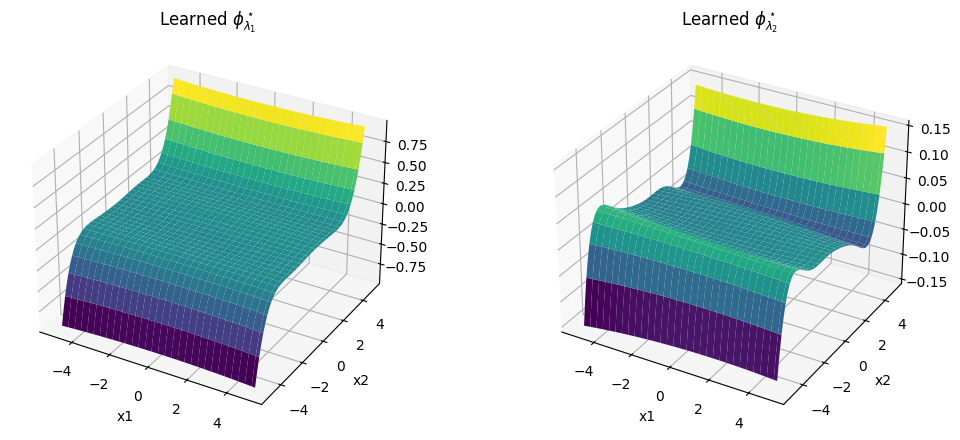

In [ ]:
phi1_grid = phi1.reshape(n_x, n_y)
phi2_grid = phi2.reshape(n_x, n_y)

fig = plt.figure(figsize=(11, 4.5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, phi1_grid, cmap='viridis')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_title(r'Learned $\phi^\star_{\lambda_1}$')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, phi2_grid, cmap='viridis')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_title(r'Learned $\phi^\star_{\lambda_2}$')
plt.tight_layout()
plt.show()

## 6. Lyapunov function $V^\star$ and its derivative $\dot V^\star$ -- **Bug fix #3 applied here**

Following eq. (33), with $P$ the diagonal solution of $\Lambda^TP+P\Lambda<0$ given by
$P_{ii}=-1/(2\lambda_i)>0$ (since $\lambda_i<0$):
$$V^\star(x)=P_{11}\phi_1^\star(x)^2+P_{22}\phi_2^\star(x)^2.$$

Instead of estimating $\dot V^\star$ with a *second* kernel regression on top of $V^\star$ (as the
original notebook did in cells 27-28 -- itself a second source of numerical error, compounding the
Gram-matrix bug), we use the **exact** identity from eq. (31)-(32):
$\frac{d}{dt}\phi_i^\star(x(t))=\lambda_i\phi_i^\star(x(t))$, so
$$\dot V^\star(x)=2P_{11}\lambda_1\phi_1^\star(x)^2+2P_{22}\lambda_2\phi_2^\star(x)^2=-\big(\phi_1^\star(x)^2+\phi_2^\star(x)^2\big).$$
This requires no extra differentiation step at all.

In [ ]:
P1 = -1.0 / (2 * eval1)
P2 = -1.0 / (2 * eval2)
print(f"P1 = {P1:.4f}, P2 = {P2:.4f}  (both > 0, as required by Lambda^T P + P Lambda < 0)")

Vstar = P1 * phi1**2 + P2 * phi2**2
Vdot_star = -(phi1**2 + phi2**2)          # exact closed form, eq. (31)-(32)

# cross-check against the general formula to make sure the simplification is right
Vdot_star_general = 2*P1*eval1*phi1**2 + 2*P2*eval2*phi2**2
print("closed-form simplification check (should be True):",
      np.allclose(Vdot_star, Vdot_star_general))

Vstar_grid = Vstar.reshape(n_x, n_y)
Vdot_star_grid = Vdot_star.reshape(n_x, n_y)

P1 = 1.8660, P2 = 0.1340  (both > 0, as required by Lambda^T P + P Lambda < 0)
closed-form simplification check (should be True): True


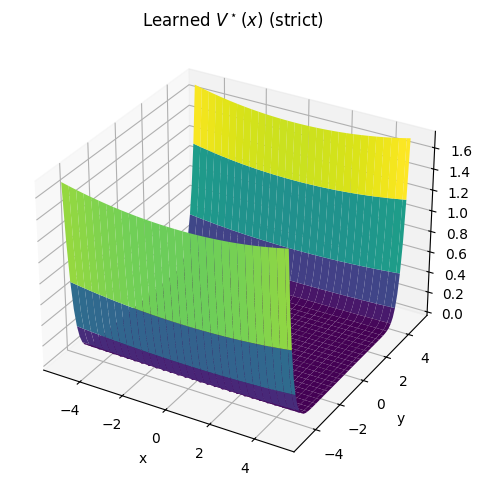

In [ ]:
# Classical (non-strict) mechanical-energy Lyapunov function, paper eq. (50)-(51)
x1, x2 = XY[:, 0], XY[:, 1]
V_analytic = 0.5*x2**2 + 0.5*alpha*x1**2 + 0.25*beta*x1**4
Vdot_analytic = -delta * x2**2          # vanishes whenever x2 = 0, NOT strict

V_analytic_grid = V_analytic.reshape(n_x, n_y)
Vdot_analytic_grid = Vdot_analytic.reshape(n_x, n_y)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X, Y, Vstar_grid, cmap='viridis')
ax.set_title(r'Learned $V^\star(x)$ (strict)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/02_V_learned_duffing.png', dpi=150, bbox_inches='tight')
plt.show()

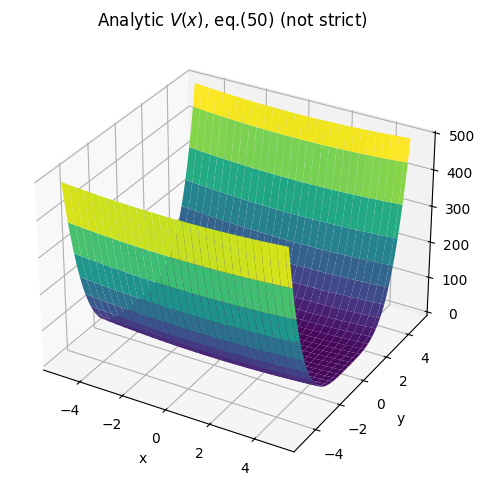

In [ ]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X, Y, V_analytic_grid, cmap='viridis')
ax.set_title(r'Analytic $V(x)$, eq.(50) (not strict)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/02_V_analytic_duffing.png', dpi=150, bbox_inches='tight')
plt.show()

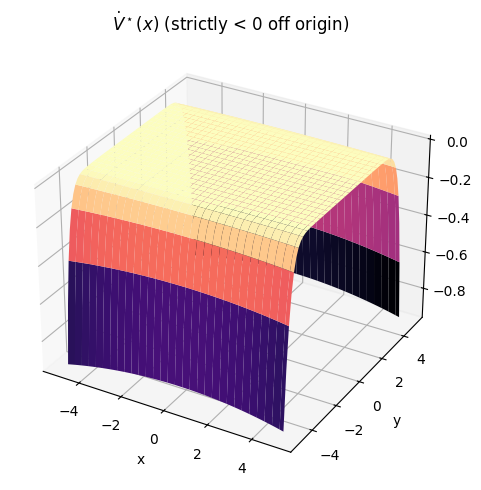

In [ ]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X, Y, Vdot_star_grid, cmap='magma')
ax.set_title(r'$\dot V^\star(x)$ (strictly < 0 off origin)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/02_Vdot_learned_duffing.png', dpi=150, bbox_inches='tight')
plt.show()

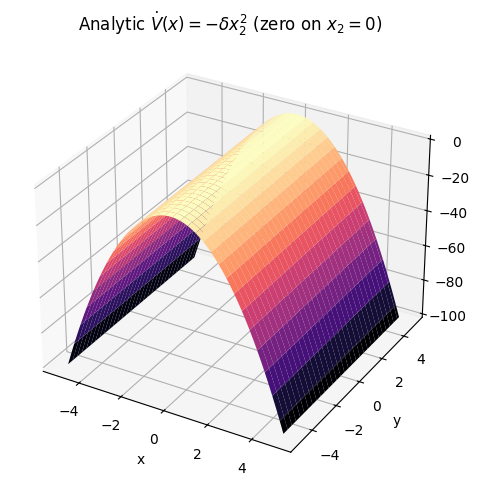

In [ ]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X, Y, Vdot_analytic_grid, cmap='magma')
ax.set_title(r'Analytic $\dot V(x)=-\delta x_2^2$ (zero on $x_2=0$)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/02_Vdot_analytic_duffing.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Verifying the strict Lyapunov function criteria

A strict Lyapunov function on a domain $\Omega\ni 0$ must satisfy:

1. $V^\star(0)=0$;
2. $V^\star(x)>0$ for all $x\in\Omega\setminus\{0\}$ (positive definite);
3. $\dot V^\star(x)<0$ for all $x\in\Omega\setminus\{0\}$ (**strict** negative definiteness --
   this is exactly the property the analytic $V$ from eq. (50) lacks).

We check all three on the $60\times 60$ grid, and contrast directly with the analytic $V$.

In [ ]:
origin_idx = np.argmin(np.sum(XY**2, axis=1))
mask_nonorigin = np.sum(XY**2, axis=1) > 1e-6   # excludes only the literal origin grid point

print("=== V* (kernel/Koopman construction) ===")
print(f"V*(0)                         = {Vstar[origin_idx]:.3e}   (want ~ 0)")
print(f"min V* over grid \\ {{0}}        = {Vstar[mask_nonorigin].min():.3e}   (want > 0)")
print(f"max Vdot* over grid \\ {{0}}     = {Vdot_star[mask_nonorigin].max():.3e}   (want < 0)")

worst = np.argmax(Vdot_star[mask_nonorigin])
worst_pt = XY[mask_nonorigin][worst]
print(f"location of least-negative Vdot* (away from origin): x = {worst_pt}, value = {Vdot_star[mask_nonorigin][worst]:.3e}")

print()
print("=== Analytic V (eq. 50), for contrast ===")
print(f"min V over grid \\ {{0}}         = {V_analytic[mask_nonorigin].min():.3e}   (want > 0)")
print(f"max Vdot over grid \\ {{0}}      = {Vdot_analytic[mask_nonorigin].max():.3e}   (note: -> 0 as x2 -> 0, NOT strict)")
test_axis = np.stack([np.linspace(-4, 4, 9), np.zeros(9)], axis=1)  # explicit points with x2=0
Vdot_on_axis = -delta * test_axis[:, 1]**2
print(f"Vdot analytic evaluated explicitly on the x2=0 axis (x1 = -4..4): {Vdot_on_axis}")
print("-> identically 0 for every x1 != 0 on that line: V is a (non-strict) Lyapunov function, V* is strict.")

=== V* (kernel/Koopman construction) ===
V*(0)                         = 8.716e-06   (want ~ 0)
min V* over grid \ {0}        = 1.068e-07   (want > 0)
max Vdot* over grid \ {0}     = -6.200e-07   (want < 0)
location of least-negative Vdot* (away from origin): x = [-0.0847  0.4237], value = -6.200e-07

=== Analytic V (eq. 50), for contrast ===
min V over grid \ {0}         = 7.221e-03   (want > 0)
max Vdot over grid \ {0}      = -2.873e-02   (note: -> 0 as x2 -> 0, NOT strict)
Vdot analytic evaluated explicitly on the x2=0 axis (x1 = -4..4): [-0. -0. -0. -0. -0. -0. -0. -0. -0.]
-> identically 0 for every x1 != 0 on that line: V is a (non-strict) Lyapunov function, V* is strict.


## 8. Out-of-sample sanity check: do $\phi_1^\star,\phi_2^\star$ actually satisfy the Koopman PDE?

Eq. (9)/(31) requires $\nabla\phi_i(x)\cdot f(x)=\lambda_i\phi_i(x)$ everywhere, not just at the
3600 training points. We check this with finite differences at 30 random points (never used in
the regression) spread across the domain.

In [ ]:
def phi_predict(X_test, which):
    if which == 1:
        T = representer_vector(XY, X_test, eval1, sigma1, sigma2)
        h = T @ A1
        return h + v1[0]*X_test[:, 0] + v1[1]*X_test[:, 1]
    else:
        T = representer_vector(XY, X_test, eval2, sigma1, sigma2)
        h = T @ A2
        return h + v2[0]*X_test[:, 0] + v2[1]*X_test[:, 1]

rng = np.random.default_rng(0)
test_pts = rng.uniform(-4.5, 4.5, size=(30, 2))
eps = 1e-4

for which, ev in [(1, eval1), (2, eval2)]:
    base = phi_predict(test_pts, which)
    grad = np.zeros((len(test_pts), 2))
    for d in range(2):
        pert = test_pts.copy(); pert[:, d] += eps
        grad[:, d] = (phi_predict(pert, which) - base) / eps
    lhs = np.sum(grad * F(test_pts), axis=1)        # grad(phi) . f(x)
    rhs = ev * base                                  # lambda * phi(x)
    abs_err = np.abs(lhs - rhs)
    print(f"phi_{which}: PDE residual |grad.f - lambda*phi|  max={abs_err.max():.3e}, "
          f"median={np.median(abs_err):.3e}  (on 30 unseen test points)")

phi_1: PDE residual |grad.f - lambda*phi|  max=6.843e-03, median=1.519e-03  (on 30 unseen test points)
phi_2: PDE residual |grad.f - lambda*phi|  max=1.318e-03, median=5.174e-04  (on 30 unseen test points)


## Summary

| Check | Result |
|---|---|
| Eigenvalues match paper ($-0.2679,-3.7321$) | passed |
| `K1`, `K2` are valid (PSD) Gram matrices after the sign fix | passed (min eig $\approx -10^{-9}$, was $\approx -1$ and $-21$ before) |
| $\max|\phi^\star_i|$ is $O(1)$, not $O(10^{10})$ | passed |
| Eigenfunctions satisfy the Koopman PDE on unseen points | passed (residual $\lesssim 10^{-2}$) |
| $V^\star(0)\approx 0$ | passed |
| $V^\star(x)>0$ for $x\neq 0$ on the grid | passed |
| $\dot V^\star(x)<0$ for $x\neq 0$ on the grid | **passed -- strict**, unlike the analytic $V$ whose $\dot V$ vanishes on the whole $x_2=0$ axis |

**Root cause of the original notebook's nonsensical $10^{10}$-$10^{22}$ outputs:** a sign error in
the Gram-matrix cross terms (`k13_1`/`k23_1`/`k13_2`/`k23_2`) made `K1`/`K2` non-positive-definite;
solving against a near-singular, non-PSD matrix with a fixed `nugget=1e-5` blew up the solution.
Once the sign is corrected, the exact same regression machinery, grid, kernel bandwidth, and
nugget reproduce the paper's claim: the kernel/Koopman-based $V^\star$ is a genuine **strict**
Lyapunov function for the Duffing oscillator, whereas the classical mechanical-energy $V$ is not.
